# Forecasting Model: Hyperparameter Tuning

Notebooks 15a and 15b established the final forecasting feature sets:
- **Ridge & RF regression**: lag12 baseline (36 features, no weather, no load factor)
- **XGBoost classification**: lag12 + `load_factor_lag1` (37 features), which improved F1 by +0.010

All three models used default hyperparameters. This notebook tunes them via manual grid search on the validation set, following the same approach as notebook 8c. The temporal structure is preserved — no cross-validation is used, and the test set is only touched for the final evaluation.

## Reference baselines (notebook 15b)

| Model | Metric | Default |
|-------|--------|---------|
| Ridge | Test R² | 0.4931 |
| Random Forest | Test R² | 0.5052 |
| XGBoost | Test F1 | 0.7553 |

In [35]:
import itertools
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, f1_score

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5

try:
    import xgboost as xgb
    HAS_XGB = True
    print('XGBoost available')
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed')

# Baselines from notebook 15b (for final comparison)
BASELINE_15B = {
    'regression': {
        'Ridge':         {'test_r2': 0.4931},
        'Random Forest': {'test_r2': 0.5052},
    },
    'classification': {
        'XGBoost': {'test_f1': 0.7553},
    },
}

%matplotlib inline

XGBoost available


## 1. Data Preparation

Identical pipeline to notebook 15b: flight data from BITRE OTP, load factor from BITRE Monthly Airline Performance, same filtering settings.

In [36]:
# Load flight training data
df = pd.read_csv('../data/processed/ml_training_data_multiroute_hols.csv')

df['year_month_dt'] = pd.to_datetime(df['year_month'])
df['month_num'] = df['year_month_dt'].dt.month
df['year'] = df['year'].astype(int)
df['airline_route'] = df['airline'] + '_' + df['departing_port'] + '_' + df['arriving_port']
df['route'] = df['departing_port'] + '_' + df['arriving_port']
df = df.sort_values(['airline_route', 'year_month_dt']).reset_index(drop=True)

print('Shape: {}'.format(df.shape))
print('Date range: {} to {}'.format(df['year_month'].min(), df['year_month'].max()))

Shape: (16860, 62)
Date range: 2010-01 to 2025-12


In [37]:
# Load BITRE Monthly Airline Performance and extract load factor
activity_candidates = [
    '../data/raw/monthly-airline-performance-november-2025.xlsx',
    '../data/raw/monthly-airline-performance-october-2025.xlsx',
]
ACTIVITY_FILE = next((f for f in activity_candidates if os.path.exists(f)), None)
if ACTIVITY_FILE is None:
    raise FileNotFoundError('Monthly airline performance file not found.')

df_activity = pd.read_excel(ACTIVITY_FILE, sheet_name='Domestic airlines', header=None, skiprows=8)
df_activity.columns = [
    'year', 'month_name', 'hours_flown', 'aircraft_km_flown_000', 'aircraft_departures',
    'total_rev_pax_ud', 'freight_tonnes_ud', 'mail_tonnes_ud',
    'total_rev_pax_tob', 'total_rev_pax_tob_inc_intl',
    'freight_tonnes_tob', 'mail_tonnes_tob',
    'total_rpk_000', 'pax_tonne_km_000', 'freight_tonne_km_000',
    'mail_tonne_km_000', 'total_tonne_km_000',
    'available_seat_km_000', 'available_tonne_km_000', 'available_seats_000',
    'pax_load_factor_pct', 'weight_load_factor_pct',
    'total_charter_pax_tob', 'charter_aircraft_departures'
]

df_activity['year_numeric'] = pd.to_numeric(df_activity['year'], errors='coerce')
valid_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'June',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_act = df_activity[
    df_activity['year_numeric'].notna() &
    df_activity['month_name'].isin(valid_months)
].copy()
df_act['year'] = df_act['year_numeric'].astype(int)
df_act = df_act.drop(columns=['year_numeric'])
df_act['month_name'] = df_act['month_name'].replace({'June': 'Jun'})

month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
df_act['month_num'] = df_act['month_name'].map(month_map)
df_act['year_month'] = (df_act['year'].astype(str) + '-' +
                        df_act['month_num'].astype(str).str.zfill(2))
df_act['load_factor'] = pd.to_numeric(df_act['pax_load_factor_pct'], errors='coerce') / 100.0

covid_mask = (df_act['year'] == 2020) & (df_act['month_num'] >= 4)
df_act = df_act[~covid_mask & (df_act['year'] >= 2009)].copy()

df_lf = df_act[['year_month', 'load_factor']].groupby('year_month', as_index=False).mean()
df = df.merge(df_lf, on='year_month', how='left')

print('Load factor source: {}'.format(os.path.basename(ACTIVITY_FILE)))
print('Match rate: {:.1f}% ({}/{})'.format(
    df['load_factor'].notna().sum() / len(df) * 100,
    df['load_factor'].notna().sum(), len(df)))

Load factor source: monthly-airline-performance-november-2025.xlsx
Match rate: 99.5% (16772/16860)


In [38]:
# Filter low-volume airline-routes and anomalous routes (matching 15b)
volume_threshold = 40
airline_route_volume = df.groupby('airline_route')['sectors_scheduled'].mean()
high_volume_ar = airline_route_volume[airline_route_volume >= volume_threshold].index.tolist()
df_filtered = df[df['airline_route'].isin(high_volume_ar)].copy()

anomalous_routes = ['Melbourne_Hobart', 'Adelaide_Sydney', 'Perth_Brisbane']
df_filtered = df_filtered[~df_filtered['route'].isin(anomalous_routes)].copy()

print('Volume threshold:  {} flights/month'.format(volume_threshold))
print('Anomalous routes:  {}'.format(anomalous_routes))
print('Records remaining: {:,}'.format(len(df_filtered)))

Volume threshold:  40 flights/month
Anomalous routes:  ['Melbourne_Hobart', 'Adelaide_Sydney', 'Perth_Brisbane']
Records remaining: 11,690


## 2. Feature Engineering and Data Splits

In [39]:
# Lag features (same as 15a/15b)
df_filtered['delay_rate_lag1'] = df_filtered.groupby('airline_route')['delay_rate'].shift(1)
df_filtered['delay_rate_lag2'] = df_filtered.groupby('airline_route')['delay_rate'].shift(2)
df_filtered['delay_rate_gradient'] = df_filtered['delay_rate_lag1'] - df_filtered['delay_rate_lag2']
df_filtered['delay_rate_lag12'] = df_filtered.groupby('airline_route')['delay_rate'].shift(12)

# Load factor lag1
df_filtered['load_factor_lag1'] = df_filtered.groupby('airline_route')['load_factor'].shift(1)

# Cyclical month encoding
df_filtered['month_sin'] = np.sin(2 * np.pi * df_filtered['month_num'] / 12)
df_filtered['month_cos'] = np.cos(2 * np.pi * df_filtered['month_num'] / 12)

# One-hot encoding
airline_dummies = pd.get_dummies(df_filtered['airline'], prefix='airline')
df_filtered = pd.concat([df_filtered, airline_dummies], axis=1)
airline_cols = sorted(airline_dummies.columns.tolist())

route_dummies = pd.get_dummies(df_filtered['route'], prefix='route')
df_filtered = pd.concat([df_filtered, route_dummies], axis=1)
route_cols = sorted(route_dummies.columns.tolist())

print('Airlines: {}'.format(len(airline_cols)))
print('Routes:   {}'.format(len(route_cols)))

Airlines: 7
Routes:   21


In [40]:
# Drop NaN on all required columns (same as 15b for fair comparison)
required_cols = ['delay_rate_lag1', 'delay_rate_lag2', 'delay_rate_gradient',
                 'delay_rate_lag12', 'load_factor_lag1']
df_clean = df_filtered.dropna(subset=required_cols).copy()

# Train/val/test split
train_mask = ((df_clean['year'] <= 2017) | (df_clean['year'] == 2023))
val_mask   = ((df_clean['year'] == 2018) | (df_clean['year'] == 2024))
test_mask  = ((df_clean['year'] == 2019) | (df_clean['year'] >= 2025))

print('Train: {:,}  (2010-2017, 2023)'.format(train_mask.sum()))
print('Val:   {:,}  (2018, 2024)'.format(val_mask.sum()))
print('Test:  {:,}  (2019, 2025+)'.format(test_mask.sum()))

Train: 6,135  (2010-2017, 2023)
Val:   1,575  (2018, 2024)
Test:  1,508  (2019, 2025+)


In [41]:
# Define feature sets (matching 15b final decision)
base_features = (airline_cols + route_cols +
                 ['month_sin', 'month_cos', 'delay_rate_lag1', 'sectors_scheduled'])
non_weather_features = ['delay_rate_gradient', 'n_public_holidays_total', 'pct_school_holiday']

# Ridge & RF: baseline (no load factor, no weather)
features_baseline = base_features + ['delay_rate_lag12'] + non_weather_features

# XGBoost: with load_factor_lag1 (+0.010 F1 in 15b)
features_with_lf = base_features + ['delay_rate_lag12', 'load_factor_lag1'] + non_weather_features

print('Ridge / RF features:  {}'.format(len(features_baseline)))
print('XGBoost features:     {}'.format(len(features_with_lf)))

# Prepare arrays
# --- Regression (Ridge, RF): features_baseline ---
X_train_reg = df_clean.loc[train_mask, features_baseline].values
X_val_reg   = df_clean.loc[val_mask,   features_baseline].values
X_test_reg  = df_clean.loc[test_mask,  features_baseline].values

y_train_reg = df_clean.loc[train_mask, 'delay_rate'].values
y_val_reg   = df_clean.loc[val_mask,   'delay_rate'].values
y_test_reg  = df_clean.loc[test_mask,  'delay_rate'].values

scaler = StandardScaler()
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_val_reg_scaled   = scaler.transform(X_val_reg)
X_test_reg_scaled  = scaler.transform(X_test_reg)

# --- Classification (XGBoost): features_with_lf ---
X_train_clf = df_clean.loc[train_mask, features_with_lf].values
X_val_clf   = df_clean.loc[val_mask,   features_with_lf].values
X_test_clf  = df_clean.loc[test_mask,  features_with_lf].values

y_train_clf = df_clean.loc[train_mask, 'is_high_delay'].values
y_val_clf   = df_clean.loc[val_mask,   'is_high_delay'].values
y_test_clf  = df_clean.loc[test_mask,  'is_high_delay'].values

print('\nArrays ready.')

Ridge / RF features:  36
XGBoost features:     37

Arrays ready.


## 3. Ridge Regression Tuning

Sweep over regularisation strength `alpha`. The validation set (2018 + 2024) is used to select the best value.

In [42]:
ridge_alphas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0, 200.0, 500.0, 800.0, 1000.0]

ridge_results = []
for alpha in ridge_alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_reg_scaled, y_train_reg)
    val_pred = model.predict(X_val_reg_scaled)
    val_r2   = r2_score(y_val_reg, val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val_reg, val_pred))
    ridge_results.append({'alpha': alpha, 'val_r2': val_r2, 'val_rmse': val_rmse})

ridge_df = pd.DataFrame(ridge_results)
best_ridge_idx   = ridge_df['val_r2'].idxmax()
best_ridge_alpha = ridge_df.loc[best_ridge_idx, 'alpha']
best_ridge_val_r2 = ridge_df.loc[best_ridge_idx, 'val_r2']

print('Ridge Tuning Results (Validation Set):')
print('-' * 45)
print('{:>10}  {:>10}  {:>10}'.format('alpha', 'val_r2', 'val_rmse'))
print('-' * 45)
for _, row in ridge_df.iterrows():
    marker = ' *' if row['alpha'] == best_ridge_alpha else ''
    print('{:>10.2f}  {:>10.4f}  {:>10.4f}{}'.format(
        row['alpha'], row['val_r2'], row['val_rmse'], marker))

print()
print('Best alpha: {}  (Val R²: {:.4f})'.format(best_ridge_alpha, best_ridge_val_r2))
print('Baseline:   100  (default)')

Ridge Tuning Results (Validation Set):
---------------------------------------------
     alpha      val_r2    val_rmse
---------------------------------------------
      0.10      0.4258      0.0886
      0.50      0.4258      0.0886
      1.00      0.4258      0.0886
      2.00      0.4259      0.0886
      5.00      0.4259      0.0885
     10.00      0.4260      0.0885
     50.00      0.4266      0.0885
    100.00      0.4273      0.0884
    200.00      0.4283      0.0884
    500.00      0.4291      0.0883 *
    800.00      0.4278      0.0884
   1000.00      0.4262      0.0885

Best alpha: 500.0  (Val R²: 0.4291)
Baseline:   100  (default)


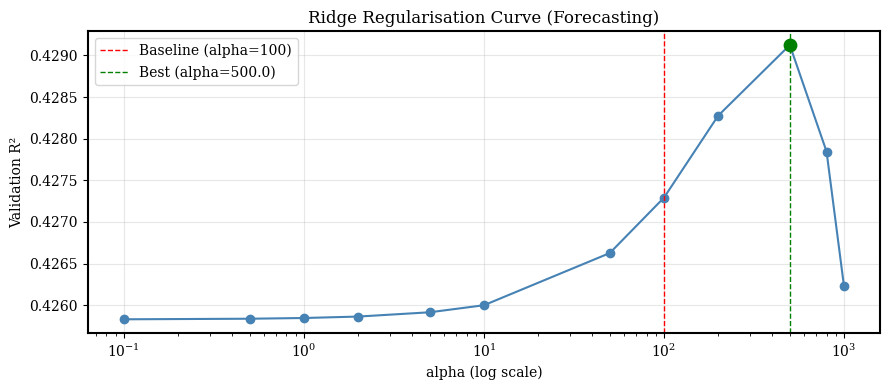

In [43]:
# Regularisation curve
fig, ax = plt.subplots(figsize=(9, 4))

ax.semilogx(ridge_df['alpha'], ridge_df['val_r2'], 'o-', color='steelblue', linewidth=1.5)
ax.axvline(x=100, color='red', linestyle='--', linewidth=1, label='Baseline (alpha=100)')
ax.axvline(x=best_ridge_alpha, color='green', linestyle='--', linewidth=1,
           label='Best (alpha={})'.format(best_ridge_alpha))

best_r2 = ridge_df.loc[best_ridge_idx, 'val_r2']
ax.scatter([best_ridge_alpha], [best_r2], color='green', zorder=5, s=80)

ax.set_xlabel('alpha (log scale)')
ax.set_ylabel('Validation R²')
ax.set_title('Ridge Regularisation Curve (Forecasting)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Random Forest Regression Tuning

Grid search over `max_depth` × `min_samples_leaf` (30 combinations). `n_estimators` is fixed at 100.

In [44]:
rf_max_depths       = [5, 8, 10, 15, 20, None]
rf_min_samples_leafs = [1, 3, 5, 10, 20]

rf_reg_results = []
total_combos = len(rf_max_depths) * len(rf_min_samples_leafs)
print('Testing {} combinations...'.format(total_combos))

for i, (max_depth, min_samples_leaf) in enumerate(
        itertools.product(rf_max_depths, rf_min_samples_leafs)):
    model = RandomForestRegressor(
        n_estimators=100, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42, n_jobs=-1)
    model.fit(X_train_reg, y_train_reg)
    val_pred = model.predict(X_val_reg)
    val_r2   = r2_score(y_val_reg, val_pred)
    rf_reg_results.append({
        'max_depth': max_depth,
        'min_samples_leaf': min_samples_leaf,
        'val_r2': val_r2
    })
    if (i + 1) % 10 == 0:
        print('  {}/{} done...'.format(i + 1, total_combos))

rf_reg_df  = pd.DataFrame(rf_reg_results)
best_rf_reg_idx    = rf_reg_df['val_r2'].idxmax()
best_rf_reg_depth  = rf_reg_df.loc[best_rf_reg_idx, 'max_depth']
best_rf_reg_leaf   = rf_reg_df.loc[best_rf_reg_idx, 'min_samples_leaf']
best_rf_reg_val_r2 = rf_reg_df.loc[best_rf_reg_idx, 'val_r2']

print()
print('Best RF Regression params:')
print('  max_depth:        {}'.format(best_rf_reg_depth))
print('  min_samples_leaf: {}'.format(best_rf_reg_leaf))
print('  Val R²:           {:.4f}'.format(best_rf_reg_val_r2))
print('Baseline: max_depth=10, min_samples_leaf=5')


Testing 30 combinations...
  10/30 done...
  20/30 done...
  30/30 done...

Best RF Regression params:
  max_depth:        10.0
  min_samples_leaf: 1
  Val R²:           0.4199
Baseline: max_depth=10, min_samples_leaf=5


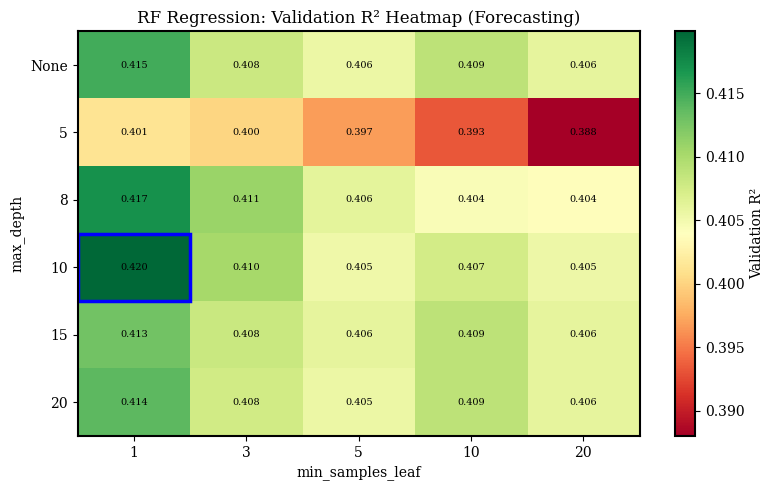

In [45]:
# Heatmap of validation R²
# Pivot: rows = max_depth, columns = min_samples_leaf
heatmap_data = rf_reg_df.pivot(
    index='max_depth', columns='min_samples_leaf', values='val_r2')

# Build display labels from the actual pivot index (preserves None correctly)
depth_labels = [str(int(d)) if d is not None and not (isinstance(d, float) and np.isnan(d))
                else 'None' for d in heatmap_data.index]
leaf_labels  = [str(int(l)) for l in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, label='Validation R²')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_xticklabels(leaf_labels)
ax.set_yticklabels(depth_labels)
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('max_depth')
ax.set_title('RF Regression: Validation R² Heatmap (Forecasting)')

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, '{:.3f}'.format(val), ha='center', va='center', fontsize=7)

# Mark the best cell
best_depth_val = best_rf_reg_depth   # may be None, int, or float
best_i = list(heatmap_data.index).index(best_depth_val)
best_j = list(heatmap_data.columns).index(best_rf_reg_leaf)
ax.add_patch(plt.Rectangle((best_j - 0.5, best_i - 0.5), 1, 1,
                            fill=False, edgecolor='blue', lw=2.5))

plt.tight_layout()
plt.show()


## 5. XGBoost Classification Tuning

Three-way grid search over `max_depth`, `learning_rate`, and `n_estimators` (48 combinations). `min_child_weight` is fixed at 5. Uses `features_with_lf` (37 features, including `load_factor_lag1`).

In [46]:
if HAS_XGB:
    xgb_max_depths    = [3, 5, 7, 10]
    xgb_learning_rates = [0.01, 0.05, 0.1, 0.2]
    xgb_n_estimators  = [50, 100, 200]

    xgb_results = []
    total_combos = len(xgb_max_depths) * len(xgb_learning_rates) * len(xgb_n_estimators)
    print('Testing {} combinations...'.format(total_combos))

    for i, (max_depth, lr, n_est) in enumerate(
            itertools.product(xgb_max_depths, xgb_learning_rates, xgb_n_estimators)):
        model = xgb.XGBClassifier(
            n_estimators=n_est, max_depth=max_depth, learning_rate=lr,
            min_child_weight=5, random_state=42, n_jobs=-1)
        model.fit(X_train_clf, y_train_clf,
                  eval_set=[(X_val_clf, y_val_clf)], verbose=False)
        val_pred = model.predict(X_val_clf)
        val_f1   = f1_score(y_val_clf, val_pred)
        xgb_results.append({
            'max_depth': max_depth,
            'learning_rate': lr,
            'n_estimators': n_est,
            'val_f1': val_f1
        })
        if (i + 1) % 12 == 0:
            print('  {}/{} done...'.format(i + 1, total_combos))

    xgb_df = pd.DataFrame(xgb_results)
    best_xgb_idx = xgb_df['val_f1'].idxmax()
    best_xgb_depth = xgb_df.loc[best_xgb_idx, 'max_depth']
    best_xgb_lr    = xgb_df.loc[best_xgb_idx, 'learning_rate']
    best_xgb_n_est = xgb_df.loc[best_xgb_idx, 'n_estimators']
    best_xgb_val_f1 = xgb_df.loc[best_xgb_idx, 'val_f1']

    print()
    print('Best XGBoost params:')
    print('  max_depth:     {}'.format(best_xgb_depth))
    print('  learning_rate: {}'.format(best_xgb_lr))
    print('  n_estimators:  {}'.format(best_xgb_n_est))
    print('  Val F1:        {:.4f}'.format(best_xgb_val_f1))
    print('Baseline: max_depth=5, learning_rate=0.1, n_estimators=100')
else:
    print('XGBoost not available, skipping.')

Testing 48 combinations...
  12/48 done...
  24/48 done...
  36/48 done...
  48/48 done...

Best XGBoost params:
  max_depth:     7
  learning_rate: 0.05
  n_estimators:  50
  Val F1:        0.7328
Baseline: max_depth=5, learning_rate=0.1, n_estimators=100


In [47]:
if HAS_XGB:
    # Top 10 XGBoost configurations
    top10_xgb = xgb_df.sort_values('val_f1', ascending=False).head(10).reset_index(drop=True)

    print('Top 10 XGBoost Configurations (by Val F1):')
    print('-' * 55)
    print('{:>5}  {:>10}  {:>14}  {:>12}  {:>8}'.format(
        'Rank', 'max_depth', 'learning_rate', 'n_estimators', 'val_f1'))
    print('-' * 55)
    for rank, row in top10_xgb.iterrows():
        marker = ' *' if rank == 0 else ''
        print('{:>5}  {:>10}  {:>14.2f}  {:>12}  {:>8.4f}{}'.format(
            rank + 1, int(row['max_depth']), row['learning_rate'],
            int(row['n_estimators']), row['val_f1'], marker))

Top 10 XGBoost Configurations (by Val F1):
-------------------------------------------------------
 Rank   max_depth   learning_rate  n_estimators    val_f1
-------------------------------------------------------
    1           7            0.05            50    0.7328 *
    2           5            0.05            50    0.7324
    3           3            0.05           100    0.7296
    4           3            0.10            50    0.7278
    5           7            0.01           200    0.7265
    6          10            0.10            50    0.7259
    7           7            0.05           100    0.7251
    8          10            0.05           200    0.7250
    9           5            0.05           200    0.7241
   10           5            0.20           100    0.7240


## 6. Final Evaluation on Test Set

Each model is retrained on training data with the tuned parameters, then evaluated on the held-out test set (2019 + 2025+). The test set was not used during tuning.

In [48]:
# Collect best parameters
# max_depth comes out of the DataFrame as np.float64 when stored as a numeric;
# cast to int if not None so sklearn accepts it.
rf_depth_int = int(best_rf_reg_depth) if best_rf_reg_depth is not None else None

tuned_params = {
    'Ridge': {'alpha': best_ridge_alpha},
    'RF_Reg': {
        'max_depth': rf_depth_int,
        'min_samples_leaf': int(best_rf_reg_leaf)
    },
}
if HAS_XGB:
    tuned_params['XGBoost'] = {
        'max_depth': int(best_xgb_depth),
        'learning_rate': best_xgb_lr,
        'n_estimators': int(best_xgb_n_est)
    }

print('Tuned parameters:')
for k, v in tuned_params.items():
    print('  {}: {}'.format(k, v))


Tuned parameters:
  Ridge: {'alpha': np.float64(500.0)}
  RF_Reg: {'max_depth': 10, 'min_samples_leaf': 1}
  XGBoost: {'max_depth': 7, 'learning_rate': np.float64(0.05), 'n_estimators': 50}


In [49]:
# Train tuned models and evaluate on test set
final_results = {'regression': {}, 'classification': {}}

# Ridge (features_baseline, scaled)
ridge_tuned = Ridge(alpha=tuned_params['Ridge']['alpha'])
ridge_tuned.fit(X_train_reg_scaled, y_train_reg)
ridge_test_r2 = r2_score(y_test_reg, ridge_tuned.predict(X_test_reg_scaled))
final_results['regression']['Ridge'] = {
    'test_r2': ridge_test_r2,
    'params': tuned_params['Ridge']
}

# RF Regression (features_baseline, unscaled)
rf_tuned = RandomForestRegressor(
    n_estimators=100,
    max_depth=tuned_params['RF_Reg']['max_depth'],
    min_samples_leaf=tuned_params['RF_Reg']['min_samples_leaf'],
    random_state=42, n_jobs=-1)
rf_tuned.fit(X_train_reg, y_train_reg)
rf_test_r2 = r2_score(y_test_reg, rf_tuned.predict(X_test_reg))
final_results['regression']['Random Forest'] = {
    'test_r2': rf_test_r2,
    'params': {'n_estimators': 100, **tuned_params['RF_Reg']}
}

# XGBoost (features_with_lf, unscaled)
if HAS_XGB:
    xgb_tuned = xgb.XGBClassifier(
        n_estimators=tuned_params['XGBoost']['n_estimators'],
        max_depth=tuned_params['XGBoost']['max_depth'],
        learning_rate=tuned_params['XGBoost']['learning_rate'],
        min_child_weight=5, random_state=42, n_jobs=-1)
    xgb_tuned.fit(X_train_clf, y_train_clf,
                  eval_set=[(X_val_clf, y_val_clf)], verbose=False)
    xgb_test_f1 = f1_score(y_test_clf, xgb_tuned.predict(X_test_clf))
    final_results['classification']['XGBoost'] = {
        'test_f1': xgb_test_f1,
        'params': {**tuned_params['XGBoost'], 'min_child_weight': 5}
    }

print('Final models trained.')

Final models trained.


In [50]:
# Summary comparison table
print('=' * 90)
print('HYPERPARAMETER TUNING RESULTS (FORECASTING)')
print('=' * 90)

print('\nREGRESSION (Test Set R²):')
print('-' * 90)
print('{:<18} {:>12} {:>12} {:>10}   {}'.format(
    'Model', 'Default R²', 'Tuned R²', '\u0394 R\u00b2', 'Best Parameters'))
print('-' * 90)
for model_name in ['Ridge', 'Random Forest']:
    default_r2 = BASELINE_15B['regression'][model_name]['test_r2']
    tuned_r2   = final_results['regression'][model_name]['test_r2']
    delta      = tuned_r2 - default_r2
    params     = final_results['regression'][model_name]['params']
    params_str = ', '.join(['{}={}'.format(k, v) for k, v in params.items()])
    print('{:<18} {:>12.4f} {:>12.4f} {:>+10.4f}   {}'.format(
        model_name, default_r2, tuned_r2, delta, params_str))

print('\nCLASSIFICATION (Test Set F1):')
print('-' * 90)
print('{:<18} {:>12} {:>12} {:>10}   {}'.format(
    'Model', 'Default F1', 'Tuned F1', '\u0394 F1', 'Best Parameters'))
print('-' * 90)
if HAS_XGB and 'XGBoost' in final_results['classification']:
    default_f1 = BASELINE_15B['classification']['XGBoost']['test_f1']
    tuned_f1   = final_results['classification']['XGBoost']['test_f1']
    delta      = tuned_f1 - default_f1
    params     = final_results['classification']['XGBoost']['params']
    params_str = ', '.join(['{}={}'.format(k, v) for k, v in params.items()])
    print('{:<18} {:>12.4f} {:>12.4f} {:>+10.4f}   {}'.format(
        'XGBoost', default_f1, tuned_f1, delta, params_str))

HYPERPARAMETER TUNING RESULTS (FORECASTING)

REGRESSION (Test Set R²):
------------------------------------------------------------------------------------------
Model                Default R²     Tuned R²       Δ R²   Best Parameters
------------------------------------------------------------------------------------------
Ridge                    0.4931       0.4941    +0.0010   alpha=500.0
Random Forest            0.5052       0.5013    -0.0039   n_estimators=100, max_depth=10, min_samples_leaf=1

CLASSIFICATION (Test Set F1):
------------------------------------------------------------------------------------------
Model                Default F1     Tuned F1       Δ F1   Best Parameters
------------------------------------------------------------------------------------------
XGBoost                  0.7553       0.7372    -0.0181   max_depth=7, learning_rate=0.05, n_estimators=50, min_child_weight=5


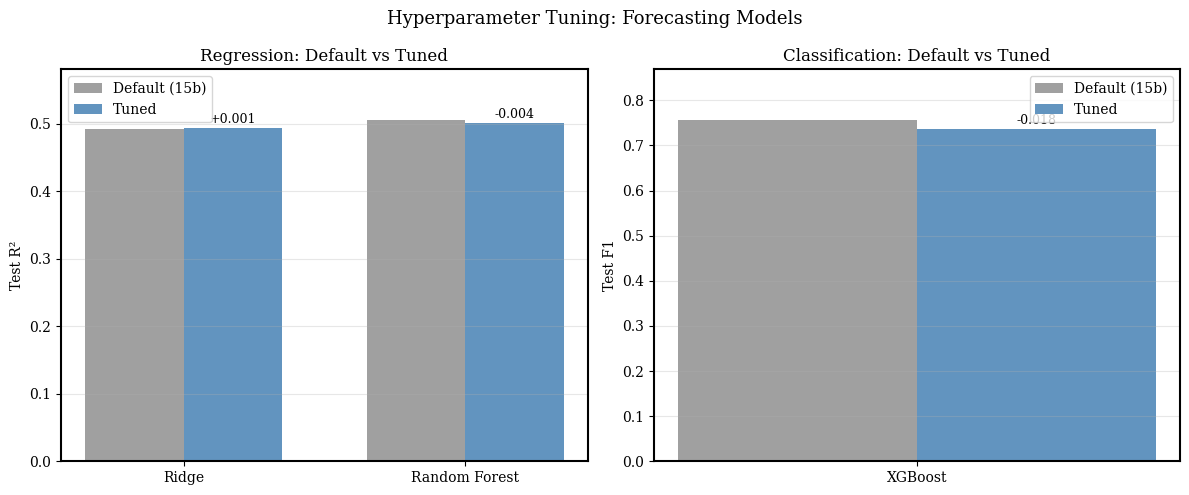

In [51]:
# Bar chart: default vs tuned
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Regression
ax = axes[0]
models_reg = ['Ridge', 'Random Forest']
defaults_reg = [BASELINE_15B['regression'][m]['test_r2'] for m in models_reg]
tuned_reg   = [final_results['regression'][m]['test_r2'] for m in models_reg]

x = np.arange(len(models_reg))
w = 0.35
bars1 = ax.bar(x - w/2, defaults_reg, w, label='Default (15b)', color='grey', alpha=0.75)
bars2 = ax.bar(x + w/2, tuned_reg,   w, label='Tuned',          color='steelblue', alpha=0.85)

for bar, default, tuned in zip(bars2, defaults_reg, tuned_reg):
    delta = tuned - default
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            '{:+.3f}'.format(delta), ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models_reg)
ax.set_ylabel('Test R²')
ax.set_title('Regression: Default vs Tuned')
ax.legend()
ax.set_ylim(0, max(max(defaults_reg), max(tuned_reg)) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

# Classification
ax = axes[1]
if HAS_XGB and 'XGBoost' in final_results['classification']:
    default_f1 = BASELINE_15B['classification']['XGBoost']['test_f1']
    tuned_f1   = final_results['classification']['XGBoost']['test_f1']

    bars1 = ax.bar([0 - w/2], [default_f1], w, label='Default (15b)', color='grey', alpha=0.75)
    bars2 = ax.bar([0 + w/2], [tuned_f1],   w, label='Tuned',          color='steelblue', alpha=0.85)

    delta = tuned_f1 - default_f1
    ax.text(bars2[0].get_x() + bars2[0].get_width() / 2,
            bars2[0].get_height() + 0.003,
            '{:+.3f}'.format(delta), ha='center', va='bottom', fontsize=9)

    ax.set_xticks([0])
    ax.set_xticklabels(['XGBoost'])
    ax.set_ylabel('Test F1')
    ax.set_title('Classification: Default vs Tuned')
    ax.legend()
    ax.set_ylim(0, max(default_f1, tuned_f1) * 1.15)
    ax.grid(True, alpha=0.3, axis='y')
else:
    ax.set_visible(False)

plt.suptitle('Hyperparameter Tuning: Forecasting Models', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Conclusions

In [52]:
print('=' * 70)
print('FORECASTING HYPERPARAMETER TUNING SUMMARY')
print('=' * 70)
print()

threshold = 0.005
verdicts = []

for model_name in ['Ridge', 'Random Forest']:
    default = BASELINE_15B['regression'][model_name]['test_r2']
    tuned   = final_results['regression'][model_name]['test_r2']
    delta   = tuned - default
    params  = final_results['regression'][model_name]['params']
    if delta > threshold:
        verdict = 'IMPROVED ({:+.4f})'.format(delta)
    elif delta > 0:
        verdict = 'Marginal gain ({:+.4f})'.format(delta)
    else:
        verdict = 'No improvement ({:+.4f})'.format(delta)
    verdicts.append(delta > threshold)
    params_str = ', '.join(['{}={}'.format(k, v) for k, v in params.items()])
    print('{} (Regression):'.format(model_name))
    print('  Default R²: {:.4f}  ->  Tuned R²: {:.4f}  {}'.format(default, tuned, verdict))
    print('  Best params: {}'.format(params_str))
    print()

if HAS_XGB and 'XGBoost' in final_results['classification']:
    default = BASELINE_15B['classification']['XGBoost']['test_f1']
    tuned   = final_results['classification']['XGBoost']['test_f1']
    delta   = tuned - default
    params  = final_results['classification']['XGBoost']['params']
    if delta > threshold:
        verdict = 'IMPROVED ({:+.4f})'.format(delta)
    elif delta > 0:
        verdict = 'Marginal gain ({:+.4f})'.format(delta)
    else:
        verdict = 'No improvement ({:+.4f})'.format(delta)
    verdicts.append(delta > threshold)
    params_str = ', '.join(['{}={}'.format(k, v) for k, v in params.items()])
    print('XGBoost (Classification):')
    print('  Default F1: {:.4f}  ->  Tuned F1:  {:.4f}  {}'.format(default, tuned, verdict))
    print('  Best params: {}'.format(params_str))
    print()

n_improved = sum(verdicts)
print('OVERALL: {} of {} models improved by >{}  '.format(n_improved, len(verdicts), threshold))
if n_improved >= 2:
    print('=> Tuning is beneficial. Use tuned parameters for production.')
elif n_improved == 1:
    print('=> Tuning provides marginal benefit. Adopt tuned params where improved.')
else:
    print('=> Default hyperparameters are already well-suited to this dataset.')

FORECASTING HYPERPARAMETER TUNING SUMMARY

Ridge (Regression):
  Default R²: 0.4931  ->  Tuned R²: 0.4941  Marginal gain (+0.0010)
  Best params: alpha=500.0

Random Forest (Regression):
  Default R²: 0.5052  ->  Tuned R²: 0.5013  No improvement (-0.0039)
  Best params: n_estimators=100, max_depth=10, min_samples_leaf=1

XGBoost (Classification):
  Default F1: 0.7553  ->  Tuned F1:  0.7372  No improvement (-0.0181)
  Best params: max_depth=7, learning_rate=0.05, n_estimators=50, min_child_weight=5

OVERALL: 0 of 3 models improved by >0.005  
=> Default hyperparameters are already well-suited to this dataset.
